In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import pandas as pd

cancer_data = load_breast_cancer()
X = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
y = pd.DataFrame(cancer_data.target, columns=['class'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)
y_train = y_train.values.ravel()

model = LogisticRegression(solver='saga', max_iter=5000)
model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'saga'
,max_iter,5000
,multi_class,'deprecated'


In [2]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 예측 결과
y_pred = model.predict(X_test)

# 정확도
accuracy = accuracy_score(y_test, y_pred)
print("accuracy: ", accuracy)

# 정밀도 (다중 클래스의 경우 average 옵션 필요)
precision = precision_score(y_test, y_pred, average='macro')  # 'macro': 클래스별 정밀도의 단순 평균, 'average': 각 클래스의 샘플 수를 가중치로 고려
print("precision: ", precision)

# 재현율
recall = recall_score(y_test, y_pred, average='macro')
print("recall: ", recall)

# F1 점수
f1 = f1_score(y_test, y_pred, average='macro')
print("f1 score: ", f1)

# 혼동 행렬
conf_matrix = confusion_matrix(y_test, y_pred)
print("\ncontusion matrix:\n", conf_matrix)


accuracy:  0.9210526315789473
precision:  0.9330103575008353
recall:  0.9090909090909092
f1 score:  0.9170641015277665

contusion matrix:
 [[40  8]
 [ 1 65]]


In [3]:
tn, fp, fn, tp = conf_matrix.ravel()

# 특이도
specificity = tn / (tn + fp)
print("Specificity:", specificity)


Specificity: 0.8333333333333334


In [5]:
# 예측 확률과 ROC Curve
from sklearn.metrics import roc_curve, roc_auc_score
y_probs = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

auc = roc_auc_score(y_test, y_probs)
print("roc-auc score: ", auc)


roc-auc score:  0.9788510101010102


Matplotlib is building the font cache; this may take a moment.


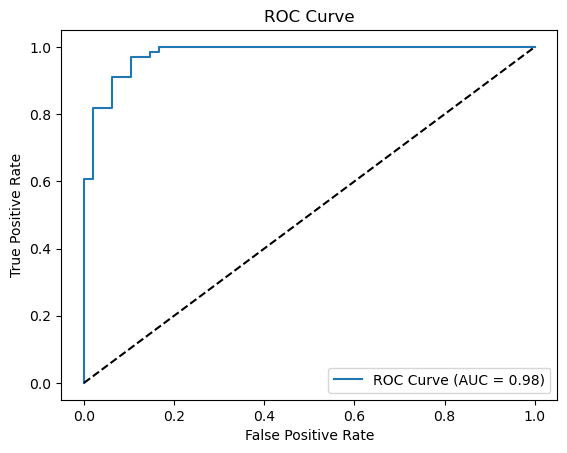

In [7]:
# 시각화
import matplotlib.pyplot as plt
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

